# Informal results script for experimental results mid-development

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%%javascript
IPython.notebook.kernel.execute('nb_name = "' + IPython.notebook.notebook_name + '"')

import os
import sys

sys.path.append(os.path.join(os.path.dirname(nb_name), '..'))

<IPython.core.display.Javascript object>

In [2]:
from plotting_functions import create_pearsons_violin

# Pre-modification results to identify gene subset to target

In [ ]:
DATA_ROOT = '../data'
results = pd.read_csv(f'{DATA_ROOT}/Pearsons_results_ACC.csv', index_col = 0, header = 0)
results['pearsons'] = 1 - results['train_loss']

In [82]:
negative_correlations = results[results['train_loss'] > 1]
negative_correlations['train_pearsons'] = 1 - negative_correlations['train_loss']
negative_correlations['test_pearsons'] = 1 - negative_correlations['test_loss']

In [83]:
negative_correlations_to_plot = negative_correlations[['train_pearsons', 'test_pearsons']]
negative_correlations_to_plot.columns = ['Train', 'Test']
negative_correlations_to_plot = negative_correlations_to_plot.melt()
negative_correlations_to_plot.columns = ['dataset', 'pearsons']
negative_correlations_to_plot.dataset.value_counts()

dataset
Train    894
Test     894
Name: count, dtype: int64

In [84]:
negative_correlations[['train_pearsons', 'test_pearsons']]['test_pearsons'].describe()

count    894.000000
mean      -0.225522
std        0.197513
min       -0.850348
25%       -0.320117
50%       -0.173309
75%       -0.070931
max        0.056655
Name: test_pearsons, dtype: float64

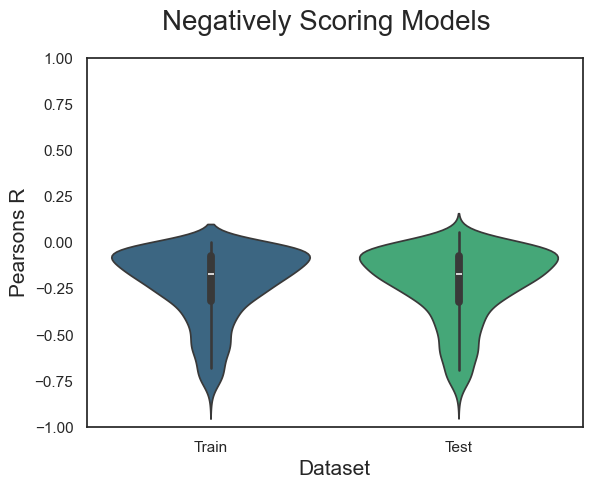

In [86]:
create_pearsons_violin(negative_correlations_to_plot, y_col = 'pearsons', title = 'Negatively Scoring Models', figure_root = './figures/experimental_figures/', file_title = 'negative_scoring_violins')

# Post-modification results to asssess change impacts

In [4]:
exp_results = pd.read_csv('../model_building/data/EXPERIMENTAL_results.csv', index_col = 0)
exp_results = pd.read_csv('/Users/alexanderbroadley/Documents/PhD/Zhang Lab/Zhang_Lab_Code/MML_model/data/PEARSONS_200_randn_all_results.csv', index_col = 0)

In [5]:
exp_results['train_pearsons'] = 1 - exp_results['train_loss']
exp_results['test_pearsons'] = 1 - exp_results['test_loss']

In [6]:
exp_results

,train_loss,test_loss,stopped_early,stopped_epoch,in_features,train_pearsons,test_pearsons
A2M,0.183568,0.178764,1,27,1196,0.816432,0.821236
A2ML1,0.226559,0.225398,1,16,1196,0.773441,0.774602
A3GALT2,0.426122,0.421012,1,32,1196,0.573878,0.578988
A4GALT,0.309817,0.307516,1,20,1196,0.690183,0.692484
AAAS,0.143026,0.138437,1,11,1196,0.856974,0.861563
...,...,...,...,...,...,...,...
ZYG11A,0.250544,0.224974,1,26,1196,0.749456,0.775026
ZYG11B,0.171656,0.162863,1,22,1196,0.828344,0.837137
ZYX,0.139909,0.141136,1,13,1196,0.860091,0.858864
ZZEF1,0.189411,0.176007,1,13,1196,0.810589,0.823993


In [7]:
exp_results[exp_results['train_pearsons'] > 0]

,train_loss,test_loss,stopped_early,stopped_epoch,in_features,train_pearsons,test_pearsons
A2M,0.183568,0.178764,1,27,1196,0.816432,0.821236
A2ML1,0.226559,0.225398,1,16,1196,0.773441,0.774602
A3GALT2,0.426122,0.421012,1,32,1196,0.573878,0.578988
A4GALT,0.309817,0.307516,1,20,1196,0.690183,0.692484
AAAS,0.143026,0.138437,1,11,1196,0.856974,0.861563
...,...,...,...,...,...,...,...
ZYG11A,0.250544,0.224974,1,26,1196,0.749456,0.775026
ZYG11B,0.171656,0.162863,1,22,1196,0.828344,0.837137
ZYX,0.139909,0.141136,1,13,1196,0.860091,0.858864
ZZEF1,0.189411,0.176007,1,13,1196,0.810589,0.823993


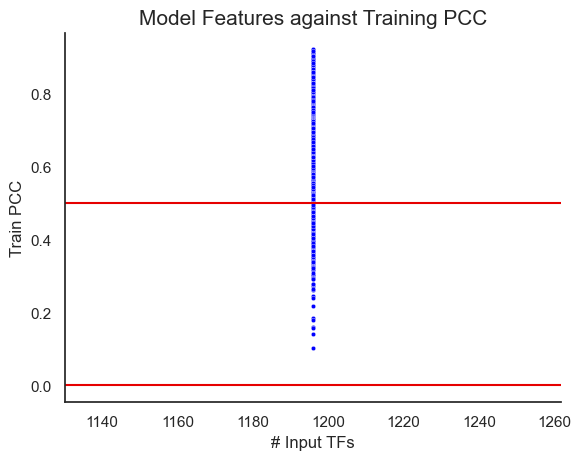

In [8]:
sns.set_theme(style = 'white')

sns.scatterplot(exp_results, y='train_pearsons', x = 'in_features', s = 10, color = '#0000ff', legend = False)
plt.ylabel('Train PCC')
plt.xlabel('# Input TFs')
plt.title('Model Features against Training PCC', fontsize = 15)
sns.despine()
plt.axhline(0.5, color = '#e60000')
plt.axhline(0.0, color = '#e60000')
plt.savefig('Experimental_feature_number_vs_trainingPCC', dpi = 300)


In [9]:
exp_results

,train_loss,test_loss,stopped_early,stopped_epoch,in_features,train_pearsons,test_pearsons
A2M,0.183568,0.178764,1,27,1196,0.816432,0.821236
A2ML1,0.226559,0.225398,1,16,1196,0.773441,0.774602
A3GALT2,0.426122,0.421012,1,32,1196,0.573878,0.578988
A4GALT,0.309817,0.307516,1,20,1196,0.690183,0.692484
AAAS,0.143026,0.138437,1,11,1196,0.856974,0.861563
...,...,...,...,...,...,...,...
ZYG11A,0.250544,0.224974,1,26,1196,0.749456,0.775026
ZYG11B,0.171656,0.162863,1,22,1196,0.828344,0.837137
ZYX,0.139909,0.141136,1,13,1196,0.860091,0.858864
ZZEF1,0.189411,0.176007,1,13,1196,0.810589,0.823993


In [10]:
exp_results[exp_results['in_features'] >30]

,train_loss,test_loss,stopped_early,stopped_epoch,in_features,train_pearsons,test_pearsons
A2M,0.183568,0.178764,1,27,1196,0.816432,0.821236
A2ML1,0.226559,0.225398,1,16,1196,0.773441,0.774602
A3GALT2,0.426122,0.421012,1,32,1196,0.573878,0.578988
A4GALT,0.309817,0.307516,1,20,1196,0.690183,0.692484
AAAS,0.143026,0.138437,1,11,1196,0.856974,0.861563
...,...,...,...,...,...,...,...
ZYG11A,0.250544,0.224974,1,26,1196,0.749456,0.775026
ZYG11B,0.171656,0.162863,1,22,1196,0.828344,0.837137
ZYX,0.139909,0.141136,1,13,1196,0.860091,0.858864
ZZEF1,0.189411,0.176007,1,13,1196,0.810589,0.823993


In [48]:
exp_results[exp_results['in_features'] >30]['stopped_early'].value_counts()

stopped_early
1.0    61
Name: count, dtype: int64

In [12]:
#transfrom dataframe to work with create_pearsons_violin
to_plot_df = exp_results[['train_pearsons', 'test_pearsons']]
to_plot_df.columns = ['Train', 'Test']
to_plot_df = to_plot_df.melt()
to_plot_df.columns = ['dataset', 'pearsons']

In [13]:
to_plot_df[to_plot_df['dataset'] == 'Train'].describe()

,pearsons
count,16100.000000
mean,0.758220
std,0.099290
min,0.102116
25%,0.715603
50%,0.783635
75%,0.827917
max,0.922608


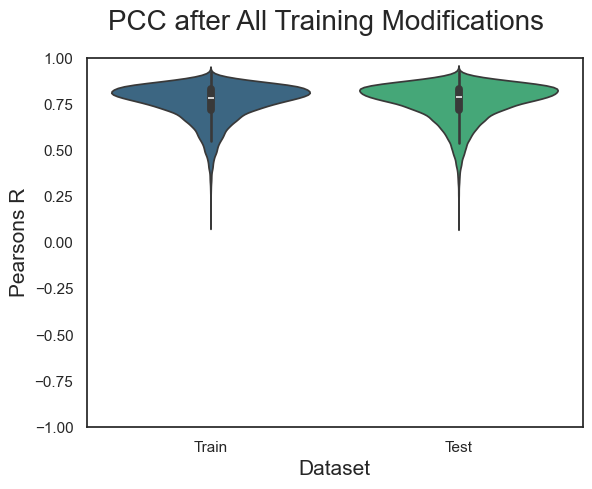

In [14]:
create_pearsons_violin(to_plot_df, y_col = 'pearsons', title = 'PCC after All Training Modifications', figure_root = './figures/_200_randn_all_TFS/', file_title = '200_randn_all_TFS', ylim = (-1, 1))

In [17]:
exp_results

,train_loss,test_loss,stopped_early,stopped_epoch,in_features,train_pearsons,test_pearsons
A2M,0.183568,0.178764,1,27,1196,0.816432,0.821236
A2ML1,0.226559,0.225398,1,16,1196,0.773441,0.774602
A3GALT2,0.426122,0.421012,1,32,1196,0.573878,0.578988
A4GALT,0.309817,0.307516,1,20,1196,0.690183,0.692484
AAAS,0.143026,0.138437,1,11,1196,0.856974,0.861563
...,...,...,...,...,...,...,...
ZYG11A,0.250544,0.224974,1,26,1196,0.749456,0.775026
ZYG11B,0.171656,0.162863,1,22,1196,0.828344,0.837137
ZYX,0.139909,0.141136,1,13,1196,0.860091,0.858864
ZZEF1,0.189411,0.176007,1,13,1196,0.810589,0.823993


In [19]:
exp_results['test_pearsons'].describe()

count    16100.000000
mean         0.760233
std          0.101744
min          0.098070
25%          0.715545
50%          0.786340
75%          0.832523
max          0.928341
Name: test_pearsons, dtype: float64